<a href="https://colab.research.google.com/github/JohnMaleek/ML/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exercise 1
Try out the effect of learning rate (linear classifier) on a different dataset from the scikit package. Visualize the model's colored confusion matrix, precision/recall and ROC curves. (2p)


[INFO] training model with learning rate: 0.0001
[INFO] training time of the logistic regression classifier: 0.0056 seconds
[INFO] accuracy: 70.00%
[INFO] training model with learning rate: 0.001
[INFO] training time of the logistic regression classifier: 0.0050 seconds
[INFO] accuracy: 72.50%
[INFO] training model with learning rate: 0.01
[INFO] training time of the logistic regression classifier: 0.0054 seconds
[INFO] accuracy: 72.50%
[INFO] training model with learning rate: 0.1
[INFO] training time of the logistic regression classifier: 0.0051 seconds
[INFO] accuracy: 80.00%


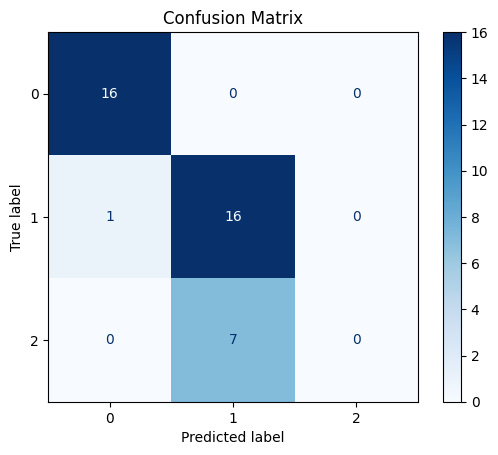

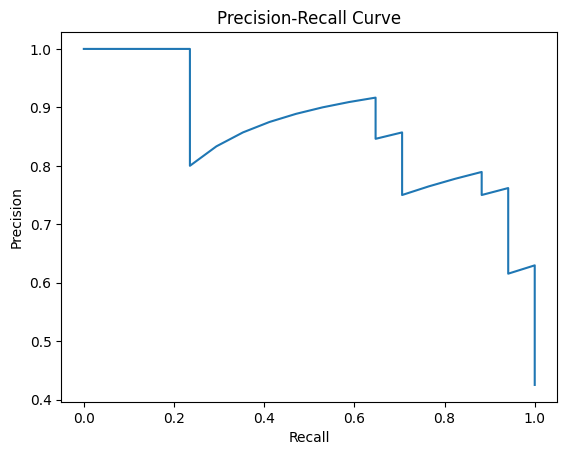

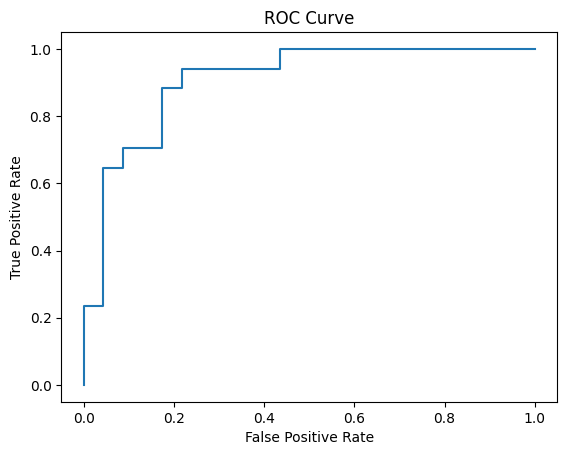

In [37]:
# Required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.linear_model import SGDClassifier
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import ConfusionMatrixDisplay
import time

(X, y) = load_wine(return_X_y=True) #I used different data set as it is asked in question
                                     # I used Load_wine data set

(X, y) = shuffle(X, y, random_state=2021) #in this process i'll split the dateset into training and test sets.

num_test = 40 #As test set 40 samples will be isolated

X_test = X[0:num_test]   #  It should be randomly shuffled
y_test = y[0:num_test]
X_train = X[num_test:]
y_train = y[num_test:]

learning_rates = [0.0001, 0.001, 0.01, 0.1] #trying different values for learning rate

models = []

for lr in learning_rates: #we put every value in the loop to try it

    print("[INFO] training model with learning rate:", lr)

    # Start timer
    start_time = time.time()

    model = SGDClassifier(
        loss="log_loss",
        learning_rate="constant",
        eta0=lr,
        max_iter=1000,
        random_state=2021
    )

    model.fit(X_train, y_train)

    # Stop timer and print training time
    training_time = time.time() - start_time
    print("[INFO] training time of the logistic regression classifier: {:.4f} seconds".format(training_time))

    models.append(model)

    predictions = model.predict(X_test)
    acc = np.mean(y_test == predictions) * 100
    print("[INFO] accuracy: {:.2f}%".format(acc))


model = models[3] # I choose model number 3 specifcally because it proves that it is the best one rather than the rest in accuracy
predictions = model.predict(X_test)  #however instead of writing static value like model[value]
                                      # we can make another loop to evaluate and comparison between them then choose the best one
                                      #but this will make the code more longer so that is the reason why i put number 3 shortly
                                      #model[3] = accuracy: 80.00%

cm = confusion_matrix(y_test, predictions) #confusion matrix is to count the number of times instances

#begin to display the graphs
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

y_scores = model.decision_function(X_test)
precision, recall, thresholds = precision_recall_curve(
    (y_test == 1).astype(int),
    y_scores[:,1]
)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

fpr, tpr, thresholds = roc_curve(
    (y_test == 1).astype(int),
    y_scores[:,1]
)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### Exercise 2
Create your own one-vs-all classifier model as a class. Inside its `fit()` method, as many binary crassifier need to be trained as the number of classes (argument or detects automatically). In the `predict()` method, we perfom predictions with all models and that classifier will make the final prediction which produced the highest probability. Try it out on the Iris dataset. (2p)

['setosa' 'versicolor' 'virginica']
[INFO] number of samples per class: {np.int64(0): np.int64(36), np.int64(1): np.int64(40), np.int64(2): np.int64(44)}
[INFO] class with largest samples (mandatory): 2
[INFO] training model for class: 0
[INFO] training model for class: 1
[INFO] training model for class: 2
[INFO] accuracy: 83.33%


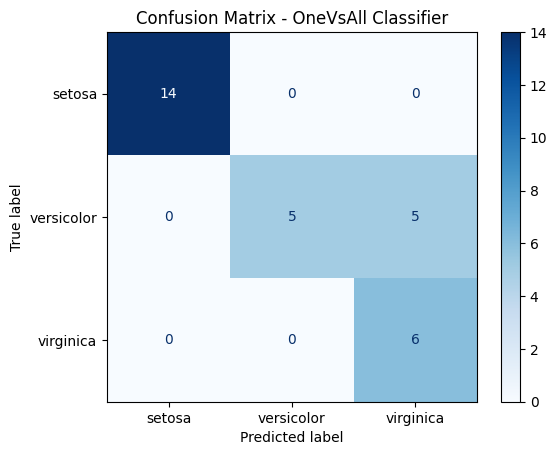

In [36]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import SGDClassifier
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


data = load_iris()
print(data.target_names) #this is to see what are target names in iris data set

# here is the Iris dataset as requested
(X, y) = load_iris(return_X_y=True)
(X, y) = shuffle(X, y, random_state=2021)

# splitting the data
num_test = 30
X_test = X[0:num_test]
y_test = y[0:num_test]
X_train = X[num_test:]
y_train = y[num_test:]

# define One-vs-All Classifier
class OneVsAllClassifier:

    def __init__(self, base_model=None): #constructor class
        self.base_model = base_model
        self.models = []
        self.num_classes = None
        self.mandatory_class = None  # class with biggest number of samples
#we need to count the number of labels and since one of these 3 labels has the biggest numbers then i'll consider it


    def fit(self, X, y):
        # count number of samples per class

        unique, counts = np.unique(y, return_counts=True)
        class_counts = dict(zip(unique, counts))
        print("[INFO] number of samples per class:", class_counts)

        #class with largest number
        self.mandatory_class = max(class_counts, key=class_counts.get)
        print("[INFO] class with largest samples (mandatory):", self.mandatory_class)

        self.num_classes = len(unique)
        self.models = []

        # train binary classifier for each class
        for cls in range(self.num_classes):
            print("[INFO] training model for class:", cls)
            y_binary = (y == cls).astype(int)
            model = SGDClassifier(
                loss="log_loss",
                learning_rate="constant",
                eta0=0.01,
                max_iter=1000,
                random_state=2021
            )
            model.fit(X, y_binary)
            self.models.append(model) #adding all of them in the array

    def predict(self, X):
        # collect confidence scores for each class
        scores = np.zeros((X.shape[0], self.num_classes))
        for cls, model in enumerate(self.models):
            scores[:, cls] = model.decision_function(X)
        predictions = np.argmax(scores, axis=1)
        return predictions

# initialize and train the One-vs-All model
ova_model = OneVsAllClassifier()
ova_model.fit(X_train, y_train)

# Evaluation process
predictions = ova_model.predict(X_test)
acc = np.mean(y_test == predictions) * 100
print("[INFO] accuracy: {:.2f}%".format(acc))

# plot Confusion Matrix
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["setosa", "versicolor", "virginica"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - OneVsAll Classifier")
plt.show()